# Clasificador de calidad de vino con KNN

## Resumen

Entreno un `KNeighborsClassifier` para predecir la calidad de un vino tinto (baja / media / alta) a partir de 11 variables químicas. El dataset viene del `UCI Wine Quality` y la `quality` original (3-8) se mapea a un `label` de 3 clases (0/1/2).

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

SEPARATOR = 120 * "-"

## 1. Carga del dataset

In [11]:
df = pd.read_csv("../data/raw/winequality-red.csv", sep=";")

print(f"Shape: {df.shape}")
print(SEPARATOR)

display(df.head())
print(SEPARATOR)

display(df.dtypes)
print(SEPARATOR)

display(df["quality"].value_counts().sort_index())

Shape: (1599, 12)
------------------------------------------------------------------------------------------------------------------------


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


------------------------------------------------------------------------------------------------------------------------


fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

------------------------------------------------------------------------------------------------------------------------


quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

## 2. Preparación de `label`

La columna `quality` viene con valores de 3 a 8. La mapeo a 3 clases: `0` baja, `1` media, `2` alta. 

,quality,label
0,5,1
1,5,1
2,5,1
3,6,1
4,5,1


------------------------------------------------------------------------------------------------------------------------


label
0      63
1    1319
2     217
Name: count, dtype: int64

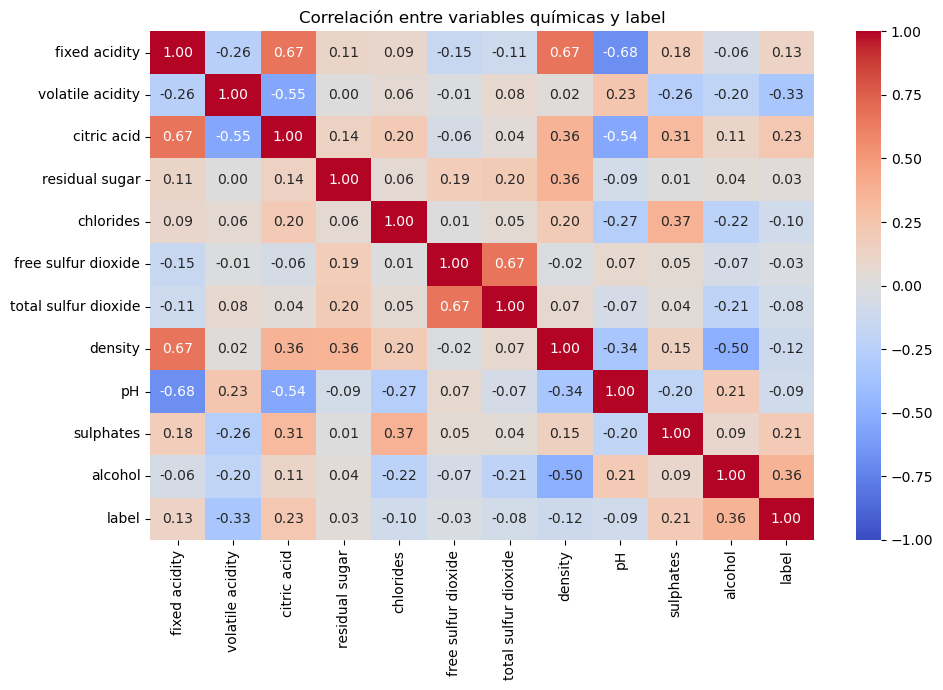

In [21]:
def to_label(q):
    if q <= 4:
        return 0  # baja
    elif q <= 6:
        return 1  # media
    else:
        return 2  # alta

df["label"] = df["quality"].apply(to_label)

display(df[["quality", "label"]].head())
print(SEPARATOR)
display(df["label"].value_counts().sort_index())

corr = df.drop(columns=["quality"]).corr()
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    ax=ax,
)
ax.set_title("Correlación entre variables químicas y label")
plt.tight_layout()
plt.show()

## 3. Split y escalado

In [13]:
X = df.drop(columns=["quality", "label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Tamaño de X_train: {X_train.shape[0]}")
print(f"Tamaño de X_test: {X_test.shape[0]}")
print(SEPARATOR)

print("Distribución de y_train:")
display(y_train.value_counts().sort_index())
print(SEPARATOR)

print("Distribución de y_test:")
display(y_test.value_counts().sort_index())

Tamaño de X_train: 1279
Tamaño de X_test: 320
------------------------------------------------------------------------------------------------------------------------
Distribución de y_train:


label
0      50
1    1055
2     174
Name: count, dtype: int64

------------------------------------------------------------------------------------------------------------------------
Distribución de y_test:


label
0     13
1    264
2     43
Name: count, dtype: int64

## 4. Modelo base con `k=5`

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

print(f"Accuracy en test: {accuracy_score(y_test, y_pred):.4f}")
print(SEPARATOR)

print("Matriz de confusión (filas = real, columnas = predicho):")

cm = confusion_matrix(y_test, y_pred)
display(pd.DataFrame(
    cm,
    index=["real 0 (baja)", "real 1 (media)", "real 2 (alta)"],
    columns=["pred 0", "pred 1", "pred 2"]
))

print(SEPARATOR)

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=["baja", "media", "alta"]))

Accuracy en test: 0.8187
------------------------------------------------------------------------------------------------------------------------
Matriz de confusión (filas = real, columnas = predicho):


,pred 0,pred 1,pred 2
real 0 (baja),0,13,0
real 1 (media),1,243,20
real 2 (alta),0,24,19


------------------------------------------------------------------------------------------------------------------------
Reporte de clasificación:
              precision    recall  f1-score   support

        baja       0.00      0.00      0.00        13
       media       0.87      0.92      0.89       264
        alta       0.49      0.44      0.46        43

    accuracy                           0.82       320
   macro avg       0.45      0.45      0.45       320
weighted avg       0.78      0.82      0.80       320



## 5. Búsqueda del mejor `k`

Pruebo `k` de 1 a 20, guardo el accuracy de cada uno y grafico para elegir el ganador.

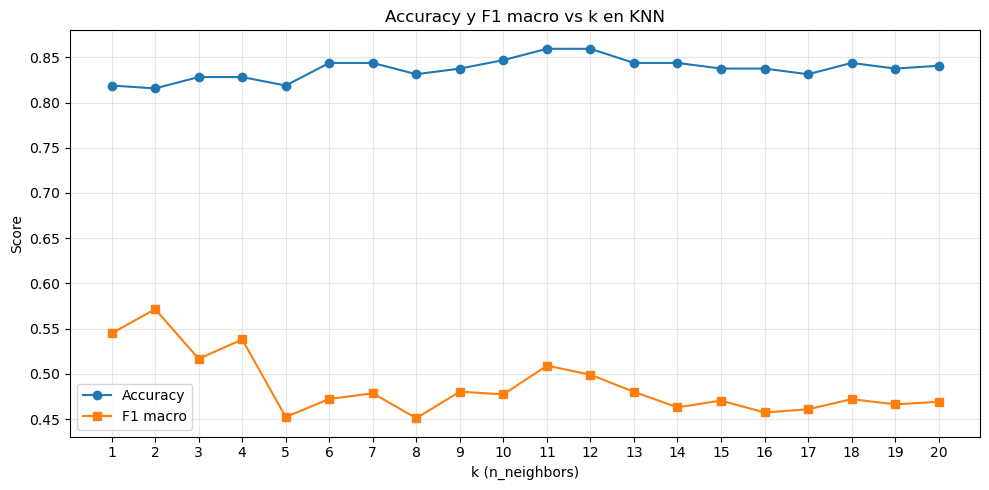

Mejor k según F1 macro: 2 (F1 macro = 0.5715)
------------------------------------------------------------------------------------------------------------------------


,k,accuracy,f1_macro
0,1,0.818750,0.544830
1,2,0.815625,0.571537
2,3,0.828125,0.516622
3,4,0.828125,0.538035
4,5,0.818750,0.452266
5,6,0.843750,0.472263
6,7,0.843750,0.478469
7,8,0.831250,0.451077
8,9,0.837500,0.480332
9,10,0.846875,0.477313


In [ ]:
k_values = range(1, 21)
accuracies = []
f1_macros = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))
    f1_macros.append(f1_score(y_test, y_pred, average="macro"))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values, accuracies, marker="o", label="Accuracy")
ax.plot(k_values, f1_macros, marker="s", label="F1 macro")
ax.set_xlabel("k (n_neighbors)")
ax.set_ylabel("Score")
ax.set_title("Accuracy y F1 macro vs k en KNN")
ax.set_xticks(list(k_values))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k_idx = int(np.argmax(f1_macros))
print(f"Mejor k según F1 macro: {list(k_values)[best_k_idx]} (F1 macro = {f1_macros[best_k_idx]:.4f})")
print(SEPARATOR)

results = pd.DataFrame({"k": list(k_values), "accuracy": accuracies, "f1_macro": f1_macros})
display(results)

## 6. `predict_wine_quality`

Reentreno con el mejor `k` y armo la función que recibe los 11 valores químicos y devuelve un texto de sommelier.

In [18]:
best_k = list(k_values)[best_k_idx]
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)

y_pred_best = knn_best.predict(X_test_scaled)

print(f"Reentrenado KNN con k={best_k}")
print(SEPARATOR)

print(f"Accuracy en test: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1 macro en test: {f1_score(y_test, y_pred_best, average='macro'):.4f}")
print(SEPARATOR)

print("Reporte de clasificación del mejor modelo:")
print(classification_report(y_test, y_pred_best, target_names=["baja", "media", "alta"]))


def predict_wine_quality(features):
    arr = np.array(features).reshape(1, -1)
    arr_scaled = scaler.transform(arr)
    pred = knn_best.predict(arr_scaled)[0]
    labels = {0: "baja", 1: "media", 2: "alta"}
    return f"Este vino probablemente sea de calidad {labels[pred]} 🍷"

print(SEPARATOR)

print(predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]))

Reentrenado KNN con k=2
------------------------------------------------------------------------------------------------------------------------
Accuracy en test: 0.8156
F1 macro en test: 0.5715
------------------------------------------------------------------------------------------------------------------------
Reporte de clasificación del mejor modelo:
              precision    recall  f1-score   support

        baja       0.22      0.38      0.28        13
       media       0.88      0.89      0.89       264
        alta       0.67      0.47      0.55        43

    accuracy                           0.82       320
   macro avg       0.59      0.58      0.57       320
weighted avg       0.83      0.82      0.82       320

------------------------------------------------------------------------------------------------------------------------
Este vino probablemente sea de calidad media 🍷


c:\Users\cerko\miniconda3\envs\data-science\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 7. Conclusiones
Resumen del `mejor modelo KNN` encontrado.

In [22]:
print(f"Mejor k (por F1 macro): {best_k}")
print(f"Accuracy final en test: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"F1 macro final en test: {f1_score(y_test, y_pred_best, average='macro'):.4f}")
print(SEPARATOR)
print("Conclusiones:")
print("- Features más informativas: alcohol (0.36) y volatile acidity (-0.33).")
print("  El resto aporta poco y agrega ruido al modelo.")
print("- El KNN distingue bien la clase media (F1 0.89) y aceptable la alta (F1 0.55).")
print("- La clase baja es la más difícil (F1 0.28) por el desbalance: solo 63/1599 vinos.")
print("- Accuracy 0.82 engañoso: predecir media siempre ya da 0.825.")
print(f"- k={best_k} es sensible al ruido por ser chico; con k=5-10 sería más estable.")
print("- Mejoras posibles: GridSearchCV con weights='distance' o probar métrica manhattan.")

Mejor k (por F1 macro): 2
Accuracy final en test: 0.8156
F1 macro final en test: 0.5715
------------------------------------------------------------------------------------------------------------------------
Conclusiones:
- Features más informativas: alcohol (0.36) y volatile acidity (-0.33).
  El resto aporta poco y agrega ruido al modelo.
- El KNN distingue bien la clase media (F1 0.89) y aceptable la alta (F1 0.55).
- La clase baja es la más difícil (F1 0.28) por el desbalance: solo 63/1599 vinos.
- Accuracy 0.82 engañoso: predecir media siempre ya da 0.825.
- k=2 es sensible al ruido por ser chico; con k=5-10 sería más estable.
- Mejoras posibles: GridSearchCV con weights='distance' o probar métrica manhattan.
